# Thick orthotropic cylinders under external pressure: Kardomateas (1993)

G. A. Kardomateas, *Buckling of thick orthotropic cylindrical shells under external pressure*, Journal of Applied Mechanics 60 (1993) 195-202.

Long (generalized plane deformation) orthotropic cylinders, inner radius $R_1 = 1$ m, outer radius $R_2$, $h = R_2 - R_1$, mean radius $R = (R_1 + R_2)/2$, under a uniform external hydrostatic pressure on the outer surface, buckling with $n = 2$:

- orthotropic material (Table 1, Figs. 2 and 5), 1 = r, 2 = $\theta$, 3 = z: $E_1 = E_3 = 14$, $E_2 = 57$, $G_{12} = G_{23} = 5.7$, $G_{31} = 5.0$ GPa, $\nu_{12} = 0.068$, $\nu_{23} = 0.277$, $\nu_{31} = 0.400$;
- isotropic material with $E = E_2 = 57$ GPa and $\nu = 0.3$ (Table 2, Fig. 5);
- references: the 3D elasticity solution and the classical shell formula, Eq. (29a), $p_{cr} = E_2 (n^2 - 1) h^3/(12 (1 - \nu_{23}\nu_{32}) R^3)$, given as $p_{cr} R_2^3/(E_2 h^3)$ for $R_2/R_1$ = 1.10 to 1.40.

These are very thick rings, $R/h$ = 10.5 to 3, where the shell theories are expected to fail. Eq. (29a) is the classical value with the follower (hydrostatic) load, $3D/R^3$ with the plane-strain bending stiffness.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import follower_utils as fu
from follower_utils import val, fmt, pct, markdown_table

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'

## panels model

A long cylinder under a uniform pressure buckles as a ring, in generalized plane strain, with the mode $w = \cos(n\theta)$, $n = 2$. The ring is modelled by `val.ring_shell`, a quarter of the circumference, $b = \pi R/2$, of a cylindrical shell with Sanders' kinematics:

- symmetry planes at the straight edges, $v = 0$ and $w_{,y} = 0$ (and $\phi_y = 0$ for the FSDT and TSDT), which contain the ring modes $n = 2, 4, \ldots$;
- symmetry planes at the ends, $u = 0$, $v_{,x} = w_{,x} = 0$, i.e. generalized plane strain;
- 4 terms along $x$ and 15 along $y$.

The pressure is a follower pressure, `add_pressure_load(-1., follower=True, cte=False, zp=zp)`, with `zp` the position of the loaded surface: `zp = h/2` places it on the outer surface, as in the elasticity solution, applied as $p(1 + z_p/R)$ per unit mid-surface area (shallow shell). The prestress comes from a linear static analysis, and the critical pressure from `val.ring_buckling_pressure`:

```python
c0 = solve(k0, s.calc_fext())
lb(k0, s.calc_kG(c=c0) + s.calc_kCfollower())
```

The fibres of the orthotropic material are along the hoop direction, i.e. plies at 90 deg, with `laminaprop = (E11, E22, nu12, G12, G13, G23) = (E2, E3, nu23, G23, G12, G31)` in the notation of the reference (1 = r, 2 = $\theta$, 3 = z): $G_{13}$ of the ply, the transverse shear stiffness `A44` of the ring, is the $r\theta$ modulus $G_{12}$ of the reference.

In [2]:
RATIOS = [1.02, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35, 1.40, 1.50, 1.60, 1.70]


def compute():
    res = {}
    for kind in ('ortho', 'iso'):
        for ratio in RATIOS:
            out = {}
            for model in ('cylshell_clpt_sanders', 'cylshell_fsdt_sanders', 'cylshell_tsdt_sanders'):
                for zp in (0., 0.5):
                    s, p = val.kardomateas1993_ring(kind, ratio, model=model, zp=zp)
                    out['%s, zp = %.1f h' % (model.split('_')[1], zp)] = p
            res['%s %.2f' % (kind, ratio)] = out
    return res


res = fu.run_or_load(os.path.join(RESULTS, 'kardomateas1993_thick_rings.json'), compute, rerun=RERUN)

computed in 248 s, saved to results/kardomateas1993_thick_rings.json


## Tables 1 and 2

$p_{cr} R_2^3/(E_2 h^3)$, differences to the elasticity solution in parentheses. `CLPT` is compared with Eq. (29a), the shell column of the paper.

In [3]:
for kind, title in (('ortho', 'Table 1, orthotropic'), ('iso', 'Table 2, isotropic')):
    rows = []
    for ratio, elast, shell in val.KARD1993[kind]:
        r = res['%s %.2f' % (kind, ratio)]
        rows.append(['%.2f' % ratio, '%.4f' % elast, '%.4f (%+.1f%%)' % (shell, pct(shell, elast)),
                     '%.4f (%+.2f%% vs Eq. 29a)' % (r['clpt, zp = 0.0 h'], pct(r['clpt, zp = 0.0 h'], shell))]
                    + ['%.4f (%+.1f%%)' % (r[m], pct(r[m], elast)) for m in
                       ('fsdt, zp = 0.0 h', 'fsdt, zp = 0.5 h', 'tsdt, zp = 0.5 h')])
    display(Markdown('**%s**' % title))
    display(Markdown(markdown_table(['$R_2/R_1$', 'elasticity', 'shell, Eq. (29a)', 'panels CLPT',
                                     'panels FSDT', 'panels FSDT, zp = h/2', 'panels TSDT, zp = h/2'], rows)))

**Table 1, orthotropic**

| $R_2/R_1$ | elasticity | shell, Eq. (29a) | panels CLPT | panels FSDT | panels FSDT, zp = h/2 | panels TSDT, zp = h/2 |
|---|---|---|---|---|---|---|
| 1.10 | 0.2728 | 0.2930 (+7.4%) | 0.2927 (-0.09% vs Eq. 29a) | 0.2823 (+3.5%) | 0.2695 (-1.2%) | 0.2695 (-1.2%) |
| 1.15 | 0.2768 | 0.3119 (+12.7%) | 0.3114 (-0.15% vs Eq. 29a) | 0.2886 (+4.3%) | 0.2697 (-2.5%) | 0.2698 (-2.5%) |
| 1.20 | 0.2784 | 0.3308 (+18.8%) | 0.3299 (-0.27% vs Eq. 29a) | 0.2908 (+4.5%) | 0.2666 (-4.2%) | 0.2666 (-4.2%) |
| 1.25 | 0.2780 | 0.3495 (+25.7%) | 0.3481 (-0.40% vs Eq. 29a) | 0.2900 (+4.3%) | 0.2610 (-6.1%) | 0.2611 (-6.1%) |
| 1.30 | 0.2762 | 0.3681 (+33.3%) | 0.3660 (-0.57% vs Eq. 29a) | 0.2869 (+3.9%) | 0.2538 (-8.1%) | 0.2539 (-8.1%) |
| 1.35 | 0.2733 | 0.3864 (+41.4%) | 0.3836 (-0.72% vs Eq. 29a) | 0.2823 (+3.3%) | 0.2457 (-10.1%) | 0.2459 (-10.0%) |
| 1.40 | 0.2696 | 0.4046 (+50.1%) | 0.4009 (-0.91% vs Eq. 29a) | 0.2767 (+2.6%) | 0.2372 (-12.0%) | 0.2376 (-11.9%) |

**Table 2, isotropic**

| $R_2/R_1$ | elasticity | shell, Eq. (29a) | panels CLPT | panels FSDT | panels FSDT, zp = h/2 | panels TSDT, zp = h/2 |
|---|---|---|---|---|---|---|
| 1.10 | 0.2999 | 0.3159 (+5.3%) | 0.3156 (-0.08% vs Eq. 29a) | 0.3124 (+4.2%) | 0.2982 (-0.6%) | 0.2982 (-0.6%) |
| 1.15 | 0.3109 | 0.3363 (+8.2%) | 0.3358 (-0.15% vs Eq. 29a) | 0.3285 (+5.7%) | 0.3071 (-1.2%) | 0.3071 (-1.2%) |
| 1.20 | 0.3209 | 0.3567 (+11.2%) | 0.3557 (-0.28% vs Eq. 29a) | 0.3428 (+6.8%) | 0.3142 (-2.1%) | 0.3142 (-2.1%) |
| 1.25 | 0.3301 | 0.3769 (+14.2%) | 0.3753 (-0.42% vs Eq. 29a) | 0.3553 (+7.6%) | 0.3198 (-3.1%) | 0.3198 (-3.1%) |
| 1.30 | 0.3384 | 0.3969 (+17.3%) | 0.3946 (-0.57% vs Eq. 29a) | 0.3663 (+8.2%) | 0.3240 (-4.2%) | 0.3240 (-4.2%) |
| 1.35 | 0.3459 | 0.4167 (+20.5%) | 0.4136 (-0.74% vs Eq. 29a) | 0.3758 (+8.6%) | 0.3271 (-5.4%) | 0.3271 (-5.4%) |
| 1.40 | 0.3528 | 0.4363 (+23.7%) | 0.4323 (-0.93% vs Eq. 29a) | 0.3839 (+8.8%) | 0.3291 (-6.7%) | 0.3292 (-6.7%) |

## Figures 2 and 5

Critical pressure against $R_2/R_1$, with the values of the tables of the paper as markers.

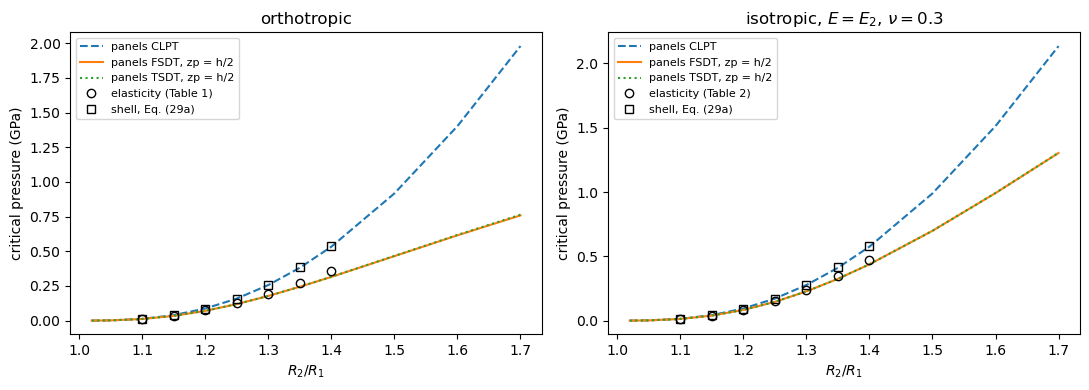

In [4]:
E2 = 57.e9
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, kind in zip(axes, ('ortho', 'iso')):
    rr = np.array(RATIOS)
    h = rr - 1.
    norm = E2*h**3/rr**3/1e9
    for label, key, st in (('panels CLPT', 'clpt, zp = 0.0 h', dict(ls='--')),
                           ('panels FSDT, zp = h/2', 'fsdt, zp = 0.5 h', dict()),
                           ('panels TSDT, zp = h/2', 'tsdt, zp = 0.5 h', dict(ls=':'))):
        ax.plot(rr, [res['%s %.2f' % (kind, r)][key]*n for r, n in zip(RATIOS, norm)], label=label, **st)
    t = np.array(val.KARD1993[kind])
    nt = E2*(t[:, 0] - 1)**3/t[:, 0]**3/1e9
    ax.plot(t[:, 0], t[:, 1]*nt, 'ko', mfc='none', label='elasticity (Table %d)' % (1 if kind == 'ortho' else 2))
    ax.plot(t[:, 0], t[:, 2]*nt, 'ks', mfc='none', label='shell, Eq. (29a)')
    ax.set_xlabel('$R_2/R_1$')
    ax.set_ylabel('critical pressure (GPa)')
    ax.set_title('orthotropic' if kind == 'ortho' else 'isotropic, $E = E_2$, $\\nu = 0.3$')
    ax.legend(fontsize=8)
plt.tight_layout()

## Discussion

- **Shell formula.** The CLPT ring with the follower pressure is 0.1% to 0.9% below Eq. (29a) for $R_2/R_1$ = 1.10 to 1.40, the extensibility of the ring, of relative order $h^2/(12R^2)$, which Eq. (29a) neglects: panels reproduces the classical hydrostatic value $3D/R^3$ with the plane-strain bending stiffness.
- **Elasticity.** The classical theory overestimates the elasticity value by 7% to 50% (orthotropic) and 5% to 24% (isotropic). The FSDT and the TSDT of panels, which account for the transverse shear, with the pressure on the outer surface, are 1.2% (orthotropic) and 0.6% (isotropic) below the elasticity value for $R_2/R_1 = 1.1$, $R/h = 10.5$, and the difference grows with the thickness, to 12% and 7% for $R_2/R_1 = 1.4$, $R/h = 3$. In this range the transverse normal strain, the variation of the prestress through the thickness, which is the reason of the maximum of $p_{cr} R_2^3/(E_2 h^3)$ of the elasticity solution, and the shallow-shell approximation of the load surface, of relative order $n^2 h/(2R)$, are significant; with the pressure on the mid-surface the FSDT overestimates the elasticity solution instead.